# Beta evidence weight and initialization probe

- **Project:** Opinion-dynamics baseline model
- **Submodel ID:** `beta-learning-rate-initialization-v0.1`
- **Parent artifact:** `single_agent_information_effect_probe.ipynb` (working-tree baseline)
- **Probe type:** mechanism probe
- **Status:** runnable draft for researcher review
- **Highest intended claim level:** V1 (isolated mechanism behavior)

This notebook tests how an agent's initial Beta concentration and the evidence credited to each consumed message jointly control belief movement and binary message-production propensity. It does **not** select or calibrate a learning rate.

## 1. Question, decision, and boundary

**Primary question.** Why does the update from $\mathrm{Beta}(2,2)$ to $\mathrm{Beta}(10,4)$ after eight supportive and two opposive messages feel too fast, and how should message evidence weight be considered together with initialization?

**Decision supported.** Choose transparent *candidate ranges* for initial concentration $\kappa_0$ and per-message evidence weight $\eta$ for later sensitivity analysis.

**Shared states and interfaces.** The private state remains $P_t\sim\mathrm{Beta}(a_t,b_t)$; the signed summary is $\Theta_t=2\mathbb{E}[P_t]-1$; public messages remain binary, $M\in\{-1,+1\}$; production uses $\Pr(M=+1)=\Pr(P_t>0.5)$.

**Boundary contract.** One isolated agent consumes fixed, homogeneous binary messages in synchronous batches. There is no network, selection process, source heterogeneity, opinion leader, media platform, forgetting, decay, or feedback from produced messages. Repeated rounds reuse the same synthetic 8/2 batch. The stopping rule is a fixed number of rounds.

A direct one-round calculation explains the posterior mean, but the notebook is useful for jointly inspecting mean movement, accumulating concentration, production probability, and repeated-round behavior.

## 2. Provenance and expected outcomes

- **Retained baseline convention:** Beta private state and posterior-mass production rule.
- **Assistant-constructed diagnostic extension:** fractional evidence update with $\eta\geq0$. Its purpose is to vary how much evidence each observed message contributes. It assumes all messages in this probe have equal evidential value.
- **Synthetic input:** eight supportive and two opposive messages per batch; it is not empirical evidence.
- **Alternatives not tested here:** bounded-memory windows, decay/forgetting, trust-weighted messages, likelihood-ratio updates, and non-Bayesian social-influence rules.

**Expected before running.** Larger $\eta$ or batch size should increase one-round movement; larger $\kappa_0$ should reduce it. Equal $\eta N/\kappa_0$ should produce equal posterior means for equal prior means and message composition, but it need not produce equal posterior-mass production probabilities. A failed invariant or non-monotonic result in these controlled cases is an implementation failure.

## 3. Minimal formalization

Initialize from a mean and concentration:

$$a_0=\mu_0\kappa_0,\qquad b_0=(1-\mu_0)\kappa_0.$$

For $n_+$ supportive and $n_-$ opposive messages, with $N=n_++n_-$ and supportive share $q=n_+/N$:

$$a_1=a_0+\eta n_+,\qquad b_1=b_0+\eta n_-.$$

The posterior mean is a weighted average:

$$\mu_1=(1-g)\mu_0+gq,\qquad g=\frac{\eta N}{\kappa_0+\eta N}.$$

Thus, $\eta$ is **per-message evidence weight**, whereas $g$ is the **realized gain for this prior and batch**. The mean path identifies their relative scale, not $\eta$ and $\kappa_0$ separately. Production also uses concentration through $\pi_+=\Pr(P_t>0.5)$, so two states with the same mean can still have different public-message propensities.

In [1]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import beta as beta_distribution


@dataclass(frozen=True)
class BetaBelief:
    a: float
    b: float

    def __post_init__(self):
        if not np.isfinite(self.a) or not np.isfinite(self.b):
            raise ValueError("Beta shape parameters must be finite.")
        if self.a <= 0 or self.b <= 0:
            raise ValueError("Beta shape parameters must be positive.")

    @property
    def concentration(self):
        return self.a + self.b

    @property
    def mean(self):
        return self.a / self.concentration

    @property
    def signed_mean(self):
        return 2.0 * self.mean - 1.0


def belief_from_mean_concentration(mean, concentration):
    mean = float(mean)
    concentration = float(concentration)
    if not 0.0 < mean < 1.0:
        raise ValueError("mean must lie strictly between 0 and 1.")
    if not np.isfinite(concentration) or concentration <= 0.0:
        raise ValueError("concentration must be finite and positive.")
    return BetaBelief(mean * concentration, (1.0 - mean) * concentration)


def support_probability(state):
    return float(beta_distribution.sf(0.5, state.a, state.b))


def belief_summary(state):
    variance = state.a * state.b / (state.concentration**2 * (state.concentration + 1.0))
    return {
        "a": state.a,
        "b": state.b,
        "mean": state.mean,
        "signed_mean": state.signed_mean,
        "concentration": state.concentration,
        "variance": variance,
        "p_support_message": support_probability(state),
    }


def _nonnegative_count(value, name):
    if isinstance(value, bool) or not isinstance(value, (int, np.integer)) or value < 0:
        raise ValueError(f"{name} must be a non-negative integer.")
    return int(value)


def update_with_evidence(state, n_support, n_oppose, evidence_weight):
    n_support = _nonnegative_count(n_support, "n_support")
    n_oppose = _nonnegative_count(n_oppose, "n_oppose")
    evidence_weight = float(evidence_weight)
    if not np.isfinite(evidence_weight) or evidence_weight < 0.0:
        raise ValueError("evidence_weight must be finite and non-negative.")
    return BetaBelief(
        state.a + evidence_weight * n_support,
        state.b + evidence_weight * n_oppose,
    )


def effective_gain(concentration, evidence_weight, batch_size):
    concentration = float(concentration)
    evidence_weight = float(evidence_weight)
    batch_size = _nonnegative_count(batch_size, "batch_size")
    if not np.isfinite(concentration) or concentration <= 0.0:
        raise ValueError("concentration must be finite and positive.")
    if not np.isfinite(evidence_weight) or evidence_weight < 0.0:
        raise ValueError("evidence_weight must be finite and non-negative.")
    return evidence_weight * batch_size / (concentration + evidence_weight * batch_size)


def transition_record(mean, concentration, n_support, n_oppose, evidence_weight):
    prior = belief_from_mean_concentration(mean, concentration)
    posterior = update_with_evidence(prior, n_support, n_oppose, evidence_weight)
    batch_size = n_support + n_oppose
    return {
        "prior_mean": prior.mean,
        "initial_concentration": prior.concentration,
        "evidence_weight": evidence_weight,
        "batch_size": batch_size,
        "support_share": n_support / batch_size if batch_size else np.nan,
        "effective_gain": effective_gain(prior.concentration, evidence_weight, batch_size),
        "posterior_mean": posterior.mean,
        "posterior_signed_mean": posterior.signed_mean,
        "signed_mean_change": posterior.signed_mean - prior.signed_mean,
        "posterior_concentration": posterior.concentration,
        "posterior_p_support": support_probability(posterior),
    }


## 4. The motivating 8/2 case

With $\mu_0=0.5$ and $\kappa_0=4$, the untempered update $\eta=1$ gives $g=10/(4+10)\approx0.714$. The new batch therefore receives about 71% of the weight in the posterior mean. Smaller evidence weights make the same ten messages less decisive.

In [2]:
worked_case = pd.DataFrame(
    [transition_record(0.5, 4, 8, 2, eta) for eta in [1.0, 0.5, 0.25, 0.10, 0.03, 0.0]]
)[
    [
        "evidence_weight",
        "effective_gain",
        "posterior_mean",
        "posterior_signed_mean",
        "posterior_concentration",
        "posterior_p_support",
    ]
]
display(worked_case.round(4))

,evidence_weight,effective_gain,posterior_mean,posterior_signed_mean,posterior_concentration,posterior_p_support
0,1.00,0.7143,0.7143,0.4286,14.0,0.9539
1,0.50,0.5556,0.6667,0.3333,9.0,0.8555
2,0.25,0.3846,0.6154,0.2308,6.5,0.7361
3,0.10,0.2000,0.5600,0.1200,5.0,0.6150
4,0.03,0.0698,0.5209,0.0419,4.3,0.5381
5,0.00,0.0000,0.5000,0.0000,4.0,0.5000


## 5. Joint initialization–evidence grid

The grid holds the prior mean and 8/2 message composition fixed. It varies only initial concentration and per-message evidence weight. The first heatmap shows belief movement; the second shows the resulting probability of producing a supportive message under the posterior-mass rule.

In [3]:
INITIAL_MEAN = 0.5
N_SUPPORT = 8
N_OPPOSE = 2
CONCENTRATIONS = [2, 4, 10, 20, 50, 100]
EVIDENCE_WEIGHTS = [0.01, 0.03, 0.10, 0.25, 0.50, 1.00]

grid = pd.DataFrame(
    [
        transition_record(INITIAL_MEAN, kappa, N_SUPPORT, N_OPPOSE, eta)
        for kappa in CONCENTRATIONS
        for eta in EVIDENCE_WEIGHTS
    ]
)
display(grid.head().round(4))

,prior_mean,initial_concentration,evidence_weight,batch_size,support_share,effective_gain,posterior_mean,posterior_signed_mean,signed_mean_change,posterior_concentration,posterior_p_support
0,0.5,2.0,0.01,10,0.8,0.0476,0.5143,0.0286,0.0286,2.1,0.5201
1,0.5,2.0,0.03,10,0.8,0.1304,0.5391,0.0783,0.0783,2.3,0.5566
2,0.5,2.0,0.10,10,0.8,0.3333,0.6000,0.2000,0.2000,3.0,0.6556
3,0.5,2.0,0.25,10,0.8,0.5556,0.6667,0.3333,0.3333,4.5,0.7844
4,0.5,2.0,0.50,10,0.8,0.7143,0.7143,0.4286,0.4286,7.0,0.8906


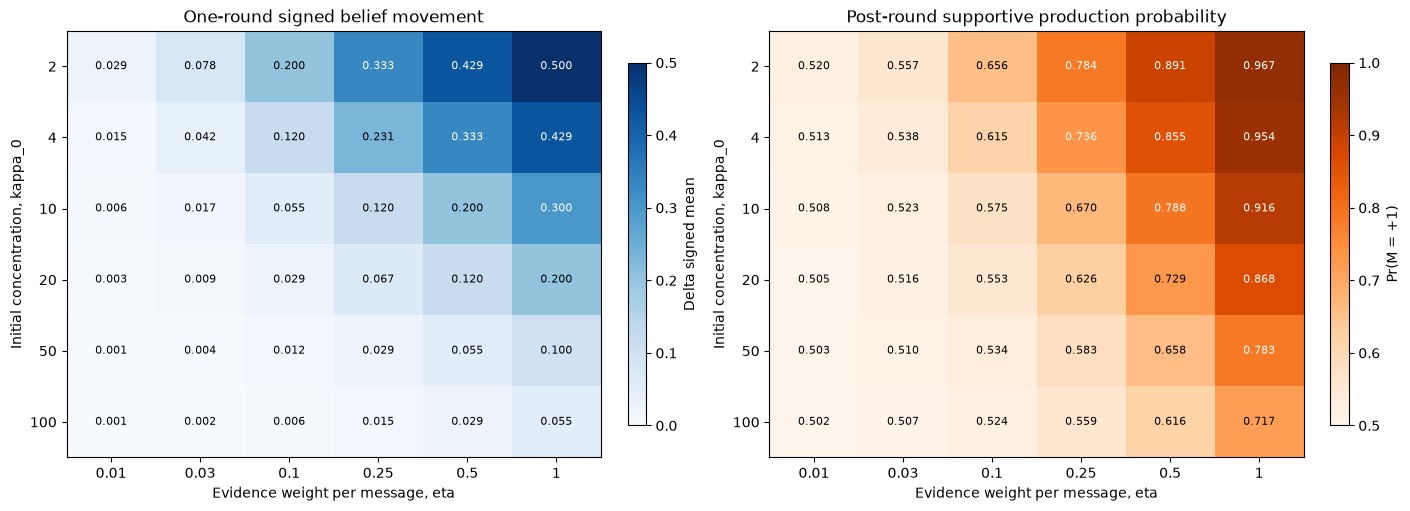

In [4]:
def draw_annotated_heatmap(ax, table, title, colorbar_label, cmap, vmin=None, vmax=None):
    values = table.to_numpy()
    image = ax.imshow(values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(table.columns)), [f"{value:g}" for value in table.columns])
    ax.set_yticks(range(len(table.index)), [f"{value:g}" for value in table.index])
    ax.set_xlabel("Evidence weight per message, eta")
    ax.set_ylabel("Initial concentration, kappa_0")
    ax.set_title(title)
    threshold = (np.nanmin(values) + np.nanmax(values)) / 2.0
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            color = "white" if values[row, column] > threshold else "black"
            ax.text(column, row, f"{values[row, column]:.3f}", ha="center", va="center", color=color, fontsize=8)
    colorbar = ax.figure.colorbar(image, ax=ax, shrink=0.85)
    colorbar.set_label(colorbar_label)


signed_change = grid.pivot(
    index="initial_concentration", columns="evidence_weight", values="signed_mean_change"
).reindex(index=CONCENTRATIONS, columns=EVIDENCE_WEIGHTS)
production_probability = grid.pivot(
    index="initial_concentration", columns="evidence_weight", values="posterior_p_support"
).reindex(index=CONCENTRATIONS, columns=EVIDENCE_WEIGHTS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
draw_annotated_heatmap(
    axes[0], signed_change, "One-round signed belief movement", "Delta signed mean", "Blues", vmin=0.0
)
draw_annotated_heatmap(
    axes[1], production_probability, "Post-round supportive production probability", "Pr(M = +1)", "Oranges", vmin=0.5, vmax=1.0
)
plt.show()

## 6. Equal mean gain does not imply equal production

Scaling $\kappa_0$ and $\eta$ by the same positive factor preserves $\eta N/\kappa_0$, so it preserves the posterior mean for a fixed message batch. It also scales the entire posterior concentration. The posterior-mass production rule can therefore yield different $\Pr(M=+1)$ values even when the signed mean is identical.

In [5]:
equivalent_gain_cases = pd.DataFrame(
    [
        {"configuration": "kappa=4, eta=0.1", **transition_record(0.5, 4, 8, 2, 0.1)},
        {"configuration": "kappa=40, eta=1.0", **transition_record(0.5, 40, 8, 2, 1.0)},
    ]
)[
    [
        "configuration",
        "effective_gain",
        "posterior_mean",
        "posterior_signed_mean",
        "posterior_concentration",
        "posterior_p_support",
    ]
]
display(equivalent_gain_cases.round(4))

,configuration,effective_gain,posterior_mean,posterior_signed_mean,posterior_concentration,posterior_p_support
0,"kappa=4, eta=0.1",0.2,0.56,0.12,5.0,0.6150
1,"kappa=40, eta=1.0",0.2,0.56,0.12,50.0,0.8042


## 7. Configure candidate evidence weights from a target reference gain

For a declared reference batch size $N_{ref}$ and a provisional target gain $g_{ref}$, invert the gain equation:

$$\eta=\frac{g_{ref}\kappa_0}{N_{ref}(1-g_{ref})}.$$

This is a configuration aid, not calibration. It forces the modeling claim to be stated in interpretable terms: how much weight should one reference batch receive relative to the initial state?

In [6]:
def evidence_weight_for_target_gain(target_gain, concentration, reference_batch_size):
    target_gain = float(target_gain)
    if not 0.0 <= target_gain < 1.0:
        raise ValueError("target_gain must lie in [0, 1).")
    concentration = float(concentration)
    if not np.isfinite(concentration) or concentration <= 0.0:
        raise ValueError("concentration must be finite and positive.")
    reference_batch_size = _nonnegative_count(reference_batch_size, "reference_batch_size")
    if reference_batch_size == 0:
        raise ValueError("reference_batch_size must be positive.")
    return target_gain * concentration / (reference_batch_size * (1.0 - target_gain))


TARGET_GAINS = [0.02, 0.05, 0.10, 0.20]
REFERENCE_BATCH_SIZE = 10
candidate_weights = pd.DataFrame(
    [
        {
            "initial_concentration": kappa,
            "target_reference_gain": gain,
            "required_evidence_weight": evidence_weight_for_target_gain(gain, kappa, REFERENCE_BATCH_SIZE),
        }
        for kappa in CONCENTRATIONS
        for gain in TARGET_GAINS
    ]
)
display(
    candidate_weights.pivot(
        index="initial_concentration",
        columns="target_reference_gain",
        values="required_evidence_weight",
    ).round(4)
)

target_reference_gain,0.02,0.05,0.10,0.20
initial_concentration,,,,
2,0.0041,0.0105,0.0222,0.05
4,0.0082,0.0211,0.0444,0.10
10,0.0204,0.0526,0.1111,0.25
20,0.0408,0.1053,0.2222,0.50
50,0.1020,0.2632,0.5556,1.25
100,0.2041,0.5263,1.1111,2.50


## 8. Repeated fixed-batch trajectories

Each round supplies the same synthetic 8/2 batch. There is no randomness, so replications and seeds are unnecessary. The comparison separates movement of the mean, accumulation of concentration, and the public production probability.

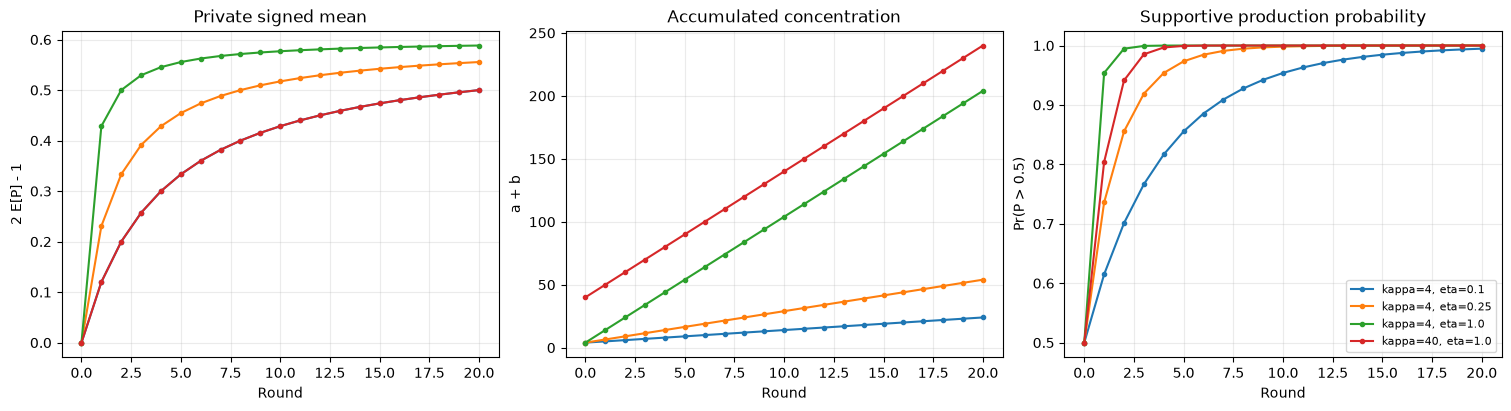

In [7]:
def fixed_batch_trajectory(label, initial_mean, initial_concentration, evidence_weight, n_support, n_oppose, rounds):
    state = belief_from_mean_concentration(initial_mean, initial_concentration)
    records = []
    for round_index in range(rounds + 1):
        records.append(
            {
                "configuration": label,
                "round": round_index,
                **belief_summary(state),
            }
        )
        if round_index < rounds:
            state = update_with_evidence(state, n_support, n_oppose, evidence_weight)
    return pd.DataFrame(records)


TRAJECTORY_CONFIGURATIONS = [
    ("kappa=4, eta=0.1", 4, 0.1),
    ("kappa=4, eta=0.25", 4, 0.25),
    ("kappa=4, eta=1.0", 4, 1.0),
    ("kappa=40, eta=1.0", 40, 1.0),
]

trajectories = pd.concat(
    [
        fixed_batch_trajectory(label, 0.5, kappa, eta, 8, 2, rounds=20)
        for label, kappa, eta in TRAJECTORY_CONFIGURATIONS
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for label, group in trajectories.groupby("configuration", sort=False):
    axes[0].plot(group["round"], group["signed_mean"], marker="o", markersize=3, label=label)
    axes[1].plot(group["round"], group["concentration"], marker="o", markersize=3, label=label)
    axes[2].plot(group["round"], group["p_support_message"], marker="o", markersize=3, label=label)

axes[0].set_title("Private signed mean")
axes[0].set_ylabel("2 E[P] - 1")
axes[1].set_title("Accumulated concentration")
axes[1].set_ylabel("a + b")
axes[2].set_title("Supportive production probability")
axes[2].set_ylabel("Pr(P > 0.5)")
for axis in axes:
    axis.set_xlabel("Round")
    axis.grid(alpha=0.25)
axes[2].legend(loc="lower right", fontsize=8)
plt.show()

## 9. Deterministic and boundary checks

These checks are deliberately hand-calculable or structural. They verify the implementation before the plots are interpreted.

In [8]:
prior = belief_from_mean_concentration(0.5, 4)
untempered = update_with_evidence(prior, 8, 2, 1.0)
assert np.isclose(untempered.a, 10.0)
assert np.isclose(untempered.b, 4.0)
assert np.isclose(untempered.mean, 10.0 / 14.0)

no_learning = update_with_evidence(prior, 8, 2, 0.0)
assert no_learning == prior

kappa_movements = [transition_record(0.5, kappa, 8, 2, 0.25)["signed_mean_change"] for kappa in CONCENTRATIONS]
assert all(left > right for left, right in zip(kappa_movements, kappa_movements[1:]))

eta_movements = [transition_record(0.5, 4, 8, 2, eta)["signed_mean_change"] for eta in EVIDENCE_WEIGHTS]
assert all(left < right for left, right in zip(eta_movements, eta_movements[1:]))

volume_movements = [
    transition_record(0.5, 4, n_support, n_oppose, 0.25)["signed_mean_change"]
    for n_support, n_oppose in [(4, 1), (8, 2), (16, 4)]
]
assert all(left < right for left, right in zip(volume_movements, volume_movements[1:]))

small_scale = transition_record(0.5, 4, 8, 2, 0.1)
large_scale = transition_record(0.5, 40, 8, 2, 1.0)
assert np.isclose(small_scale["posterior_mean"], large_scale["posterior_mean"])
assert not np.isclose(small_scale["posterior_p_support"], large_scale["posterior_p_support"])

small_path = fixed_batch_trajectory("small", 0.5, 4, 0.1, 8, 2, rounds=20)
large_path = fixed_batch_trajectory("large", 0.5, 40, 1.0, 8, 2, rounds=20)
assert np.allclose(small_path["mean"], large_path["mean"])
assert np.allclose(10.0 * small_path["concentration"], large_path["concentration"])
assert not np.allclose(small_path.loc[1:, "p_support_message"], large_path.loc[1:, "p_support_message"])

assert grid["posterior_mean"].between(0.0, 1.0, inclusive="neither").all()
assert grid["posterior_p_support"].between(0.0, 1.0, inclusive="both").all()
assert (grid["posterior_concentration"] > 0.0).all()

for invalid_call in [
    lambda: update_with_evidence(prior, -1, 2, 0.1),
    lambda: update_with_evidence(prior, 1.5, 2, 0.1),
    lambda: update_with_evidence(prior, 8, 2, -0.1),
    lambda: belief_from_mean_concentration(0.5, 0),
    lambda: evidence_weight_for_target_gain(1.0, 4, 10),
]:
    try:
        invalid_call()
    except ValueError:
        pass
    else:
        raise AssertionError("Invalid input was accepted.")

print("All deterministic and boundary checks passed.")

All deterministic and boundary checks passed.


## 10. Conditional interpretation and disposition

- The apparent speed of the $\mathrm{Beta}(2,2)\rightarrow\mathrm{Beta}(10,4)$ update is not caused by the Beta representation alone. With $\eta=1$, ten new observations outweigh an initial concentration of four.
- A candidate $\eta$ should therefore be reported together with $\kappa_0$ and a reference batch size. Reporting only a generic ‘learning rate’ hides the actual gain.
- Mean trajectories cannot separately identify the absolute scales of $\eta$ and $\kappa_0$. The posterior-mass production rule can distinguish them because it responds to concentration as well as location.
- Constant $\eta$ causes responsiveness to decline as concentration accumulates. If agents should remain responsive indefinitely, forgetting, decay, bounded memory, or a changing evidence rule would be a separate mechanism—not a numerical correction inside this probe.
- These results establish implementation behavior only (V1). They do not establish psychological realism, empirical validity, or a calibrated parameter value.

**Disposition:** unresolved pending researcher inspection and sensitivity choices. Retain this notebook as a diagnostic benchmark; do not yet integrate a specific $\eta$ into the baseline model.